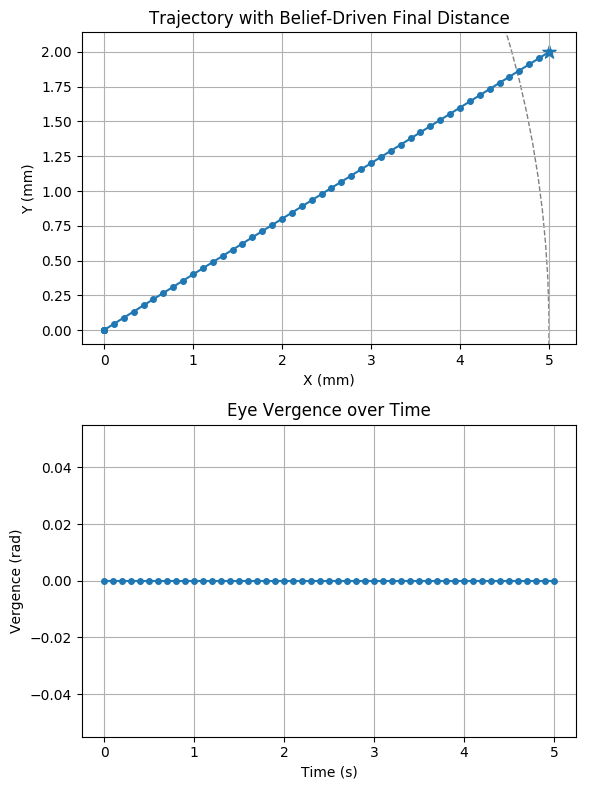

In [3]:
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# Parameters
T = 5.0   # Time horizon (s)
N = 50    # Time steps
dt = T / N

# Constraints
omega_max = np.pi        # max body turn rate (rad/s)
omega_eye_max = np.pi    # max eye speed (rad/s)
v_max = 10.0             # max swim speed (mm/s)

# Positions
p0 = np.array([0.0, 0.0])       # fish start
food_pos = np.array([5.0, 2.0]) # prey location

# Detection params
sensing_range = 5.0                     # detection range (mm)
fov_eye = np.deg2rad(10)                # per-eye half FOV

# Energy weights
lambda_swim = 1.0
lambda_body = 0.5
lambda_eye = 0.05

# Final distance penalty weight
lambda_final = 100.0

def wrap_angle_diff(a, b):
    return ((a - b + np.pi) % (2*np.pi)) - np.pi

# Unpack control vector
def unpack(u):
    u_swim = u[:N]
    u_body = u[N:2*N]
    u_L    = u[2*N:3*N]
    u_R    = u[3*N:4*N]
    return u_swim, u_body, u_L, u_R

# Simulate fish and belief
def simulate(u):
    u_swim, u_body, u_L, u_R = unpack(u)
    p = np.zeros((N+1, 2))
    phi = np.zeros(N+1)
    thetaL = np.zeros(N+1)
    thetaR = np.zeros(N+1)
    k = np.zeros(N+1, dtype=int)      # knowledge flag
    m = np.zeros((N+1, 2))            # belief

    p[0], phi[0], thetaL[0], thetaR[0] = p0, 0.0, 0.0, 0.0
    k[0] = 0

    for i in range(N):
        # Dynamics
        phi[i+1] = phi[i] + dt * u_body[i]
        thetaL[i+1] = thetaL[i] + dt * u_L[i]
        thetaR[i+1] = thetaR[i] + dt * u_R[i]
        direction = np.array([np.cos(phi[i]), np.sin(phi[i])])
        p[i+1] = p[i] + dt * u_swim[i] * direction

        # Belief update
        k[i+1] = k[i]
        m[i+1] = m[i]
        if k[i] == 0:
            vec = food_pos - p[i+1]
            dist = np.linalg.norm(vec)
            if dist <= sensing_range:
                angle_to_food = np.arctan2(vec[1], vec[0])
                left_gaze = phi[i+1] + thetaL[i+1]
                right_gaze = phi[i+1] + thetaR[i+1]
                err_L = wrap_angle_diff(left_gaze, angle_to_food)
                err_R = wrap_angle_diff(right_gaze, angle_to_food)
                if abs(err_L) <= fov_eye and abs(err_R) <= fov_eye:
                    k[i+1] = 1
                    m[i+1] = food_pos

    return p, phi, thetaL, thetaR, k, m

# Objective: energy cost + final distance to belief
def objective(u):
    p, phi, thetaL, thetaR, k, m = simulate(u)
    # Energy cost
    u_swim, u_body, u_L, u_R = unpack(u)
    energy = np.sum(lambda_swim * u_swim**2 +
                    lambda_body * u_body**2 +
                    lambda_eye * (u_L**2 + u_R**2)) * dt
    # Final distance penalty
    final_dist = np.linalg.norm(p[-1] - m[-1])
    return energy + lambda_final * final_dist

# Seed: rotate then swim
distance = np.linalg.norm(food_pos - p0)
angle_to_food = np.arctan2(food_pos[1] - p0[1], food_pos[0] - p0[0])
N_rot = 5
T_rot = N_rot * dt
u_swim0 = np.concatenate([np.zeros(N_rot), np.full(N-N_rot, distance/(T-T_rot))])
u_body0 = np.concatenate([np.full(N_rot, angle_to_food/T_rot), np.zeros(N-N_rot)])
u_L0 = np.zeros(N)
u_R0 = np.zeros(N)
u0 = np.concatenate([u_swim0, u_body0, u_L0, u_R0])

# Bounds
bounds = [(0, v_max)]*N + [(-omega_max, omega_max)]*N + \
         [(-omega_eye_max, omega_eye_max)]*N + [(-omega_eye_max, omega_eye_max)]*N

# Optimize
res = minimize(objective, u0, method='L-BFGS-B', bounds=bounds)

# Simulate optimized trajectory
opt_p, opt_phi, opt_thetaL, opt_thetaR, opt_k, opt_m = simulate(res.x)
time = np.linspace(0, T, N+1)
vergence = opt_thetaL - opt_thetaR

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 8))

# Path
ax1.plot(opt_p[:,0], opt_p[:,1], '-o', markersize=4)
ax1.scatter(food_pos[0], food_pos[1], marker='*', s=100)
ax1.add_artist(plt.Circle(p0, sensing_range, color='gray', fill=False, linestyle='--'))
ax1.set_title('Trajectory with Belief-Driven Final Distance')
ax1.set_xlabel('X (mm)'); ax1.set_ylabel('Y (mm)')
ax1.grid(True)

# Vergence
ax2.plot(time, vergence, '-o', markersize=4)
ax2.set_title('Eye Vergence over Time')
ax2.set_xlabel('Time (s)'); ax2.set_ylabel('Vergence (rad)')
ax2.grid(True)

plt.tight_layout()
plt.show()
